In [3]:
!pip install pandas 

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install adjustText

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
    --------------------------------------- 0.8/37.3 MB 4.6 MB/s eta 0:00:08
   - -------------------------------------- 1.8/37.3 MB 5.1 MB/s eta 0:00:08
   --- ------------------------------------ 3.1/37.3 MB 5.5 MB/s eta 0:00:07
   ---- ----------------------------------- 4.2/37.3 MB 5.4 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/37.3 MB 5.2 MB/s eta 0:00:07
   ------ --------------------------------- 6.3/37.3 MB 5.1 MB/s eta 0:00:07
   ------- -------------------------------- 7.1/37.3 MB 5.0 MB/s eta 0:00:06
   -------- ------------------------------- 8.1/37.3 MB 5.0 MB/s eta 0:00:06
   --------- ------------------------------ 9.2/37.3 MB 5.0 MB/s eta 0:00:06
   ---------- ----------------------------- 10.2/37.3 MB 4.9 MB/s eta 0:00:06
   ------------ --------------------------- 11.3/37.3 MB 5.0 MB/s eta 0:00:06
   


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Concat pictures full_video_timeline

In [ ]:
import os
from PIL import Image

# ==========================================
# CẤU HÌNH ĐỂ ẢNH SIÊU NÉT (TĂNG DPI LÊN 600)
# ==========================================
dpi = 600 # Tăng gấp đôi DPI để giữ lại mọi chi tiết chữ
target_w_in = 2.95
target_h_in = 1.3

target_w_px = int(target_w_in * dpi) 
target_h_px = int(target_h_in * dpi)  

gap_x = int(0.2 * dpi) # Khoảng cách ngang tương đương 0.2 inch
gap_y = int(0.1 * dpi) # Khoảng cách dọc tương đương 0.1 inch

image_dir = '.' 

# Cấu trúc ảnh
regular_rows = [
    ("full_video_timeline_ann_001_per.png", "full_video_timeline_ann_001_veh.png"),
    ("full_video_timeline_ann_002_per.png", "full_video_timeline_ann_002_veh.png"),
    ("full_video_timeline_gost_001_per.png", "full_video_timeline_gost_001_veh.png"),
    ("full_video_timeline_gost_002_per.png", "full_video_timeline_gost_002_veh.png"),
    ("full_video_timeline_zag_001_per.png", "full_video_timeline_zag_001_veh.png")
]
bottom_center_img = "full_video_timeline_dvor_001_veh.png"

# Tính toán khuôn nền
num_rows = len(regular_rows) + 1 
canvas_w = (target_w_px * 2) + gap_x
canvas_h = (target_h_px * num_rows) + (gap_y * (num_rows - 1))

canvas = Image.new('RGB', (canvas_w, canvas_h), 'white')

def process_and_paste(filename, x, y):
    filepath = os.path.join(image_dir, filename)
    if os.path.exists(filepath):
        img = Image.open(filepath)
        # Giữ lại Image.Resampling.LANCZOS vì đây là thuật toán tốt nhất cho việc thu nhỏ
        img = img.resize((target_w_px, target_h_px), Image.Resampling.LANCZOS)
        canvas.paste(img, (x, y))
    else:
        print(f"Cảnh báo: Không tìm thấy ảnh '{filename}'.")

print("Đang xử lý ghép ảnh với độ phân giải cao (600 DPI)...")

current_y = 0
for left_img, right_img in regular_rows:
    process_and_paste(left_img, 0, current_y)
    process_and_paste(right_img, target_w_px + gap_x, current_y)
    current_y += target_h_px + gap_y

center_x = (canvas_w - target_w_px) // 2
process_and_paste(bottom_center_img, center_x, current_y)

output_filename = "Ghep_Anh_Luan_Van_Sieu_Net.png"
# Lưu với thông số 600 DPI
canvas.save(output_filename, dpi=(dpi, dpi)) 

print(f"Hoàn thành! Đã lưu file: '{output_filename}'")

# 2. Creating graphic

Компромисс между скрытностью и сложностью сцены

<>:57: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:57: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_22816\1155581518.py:57: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.text(180, 100.2, 'Зона высокой скрытности\n(Invis $\geq$ 99%)',
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


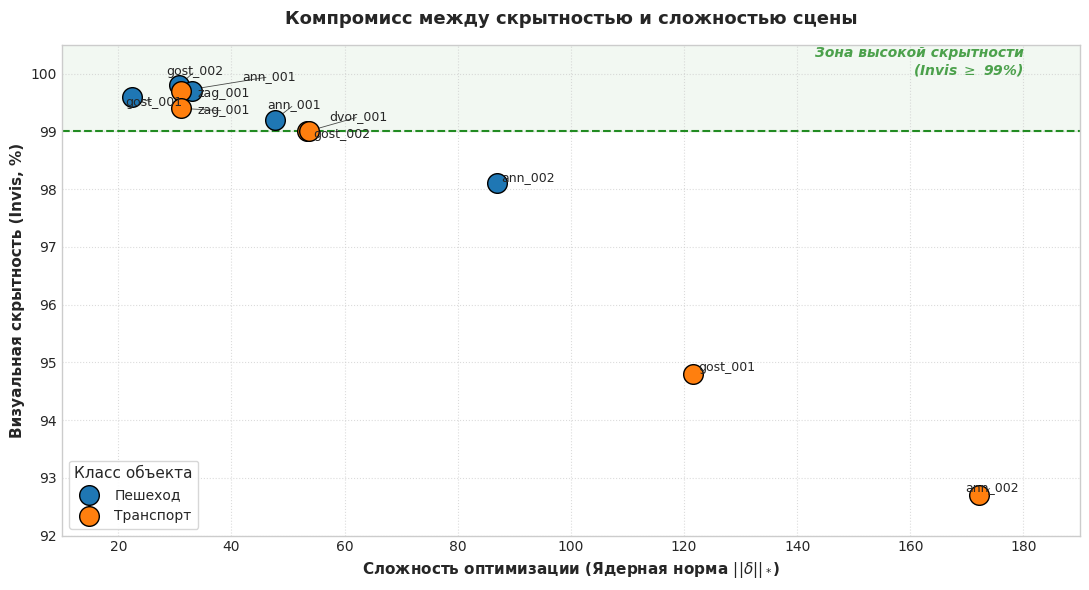

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from adjustText import adjust_text # Thư viện chống chồng chéo text

# Thiết lập style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

# Dữ liệu từ bảng 1.1
data = {
    'Video': ['ann_001', 'ann_001', 'ann_002', 'ann_002', 'dvor_001', 
              'gost_001', 'gost_001', 'gost_002', 'gost_002', 'zag_001', 'zag_001'],
    'Class': ['Пешеход', 'Транспорт', 'Пешеход', 'Транспорт', 'Транспорт',
              'Пешеход', 'Транспорт', 'Пешеход', 'Транспорт', 'Пешеход', 'Транспорт'],
    'Nuclear_Norm': [47.62, 31.16, 86.86, 172.14, 53.40, 
                     22.43, 121.67, 30.75, 53.65, 33.03, 31.03],
    'Invis_Pct': [99.2, 99.7, 98.1, 92.7, 99.0, 
                  99.6, 94.8, 99.8, 99.0, 99.7, 99.4]
}

df = pd.DataFrame(data)
colors = {'Пешеход': '#1f77b4', 'Транспорт': '#ff7f0e'}

# Đổi tỷ lệ khung hình sang dạng chữ nhật nằm ngang, gọn gàng hơn
fig, ax = plt.subplots(figsize=(11, 6))

# Vẽ các điểm scatter
for cls in df['Class'].unique():
    subset = df[df['Class'] == cls]
    ax.scatter(subset['Nuclear_Norm'], subset['Invis_Pct'], 
               color=colors[cls], s=200, label=cls, edgecolor='black', zorder=5, alpha=1)

# ---------------------------------------------------------
# XỬ LÝ CHỐNG CHỒNG CHÉO TEXT (Sử dụng adjustText)
# ---------------------------------------------------------
texts = []
for i in range(len(df)):
    # Chỉ tạo đối tượng text, chưa vẽ vội
    texts.append(ax.text(df['Nuclear_Norm'].iloc[i], df['Invis_Pct'].iloc[i], 
                         df['Video'].iloc[i], fontsize=9, zorder=6))

# Thuật toán tự động đẩy các text ra xa nhau và nối bằng vạch mờ
adjust_text(texts, 
            arrowprops=dict(arrowstyle="-", color='black', lw=0.6, alpha=0.7),
            expand_points=(1.5, 1.5),
            ax=ax)
# ---------------------------------------------------------

# Phân chia các vùng không gian
ax.axhline(y=99.0, color='forestgreen', linestyle='--', linewidth=1.5, zorder=0.9)

# Tô màu nền nhẹ cho vùng lý tưởng và di chuyển chữ ra góc trống
ax.fill_between([-10, 200], 99, 101, color='forestgreen', alpha=0.06, zorder=0)
# Đặt chữ ở góc trên cùng bên phải của vùng xanh (nơi không có điểm dữ liệu)
ax.text(180, 100.2, 'Зона высокой скрытности\n(Invis $\geq$ 99%)', 
        color='forestgreen', alpha=0.8, ha='right', va='center', 
        fontsize=10, style='italic', fontweight='bold', zorder=1)

# Thiết lập trục
ax.set_xlabel('Сложность оптимизации (Ядерная норма $||\\delta||_*$)', fontsize=11, fontweight='bold')
ax.set_ylabel('Визуальная скрытность (Invis, %)', fontsize=11, fontweight='bold')
ax.set_title('Компромисс между скрытностью и сложностью сцены', fontsize=13, fontweight='bold', pad=15)

# Tối ưu hóa giới hạn trục để giảm khoảng trống
ax.set_ylim(92, 100.5)
ax.set_xlim(10, 190)

# Đặt Legend vào góc dưới cùng bên trái (khu vực trống)
legend = ax.legend(title='Класс объекта', fontsize=10, title_fontsize=11, loc='lower left', 
                   frameon=True, facecolor='white', framealpha=0.9)
legend.get_frame().set_edgecolor('lightgray')

# Tinh chỉnh lưới
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Lưu ảnh với chất lượng cao
plt.savefig('uap_tradeoff_scatter_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. onfidence drop

<>:93: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:93: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_23708\2573961674.py:93: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_ylabel('$\Delta$conf, %', fontsize=10, fontweight='bold')


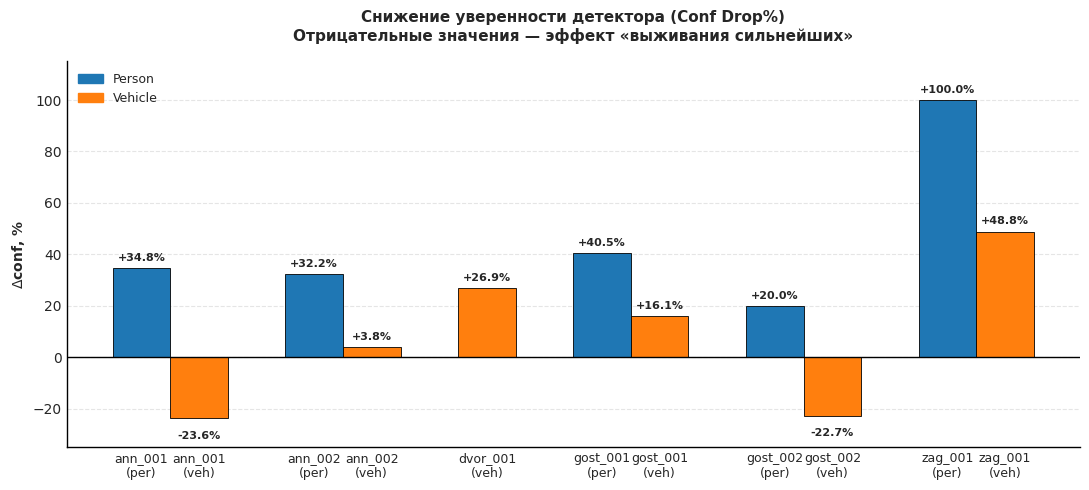

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Thiết lập font và style cơ bản
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Khai báo dữ liệu từ bảng (Cột Conf Drop %)
# Cấu trúc: Tên video ngắn gọn, giá trị Person, giá trị Vehicle
data = [
    {"video": "ann_001", "person": 34.80, "vehicle": -23.55},
    {"video": "ann_002", "person": 32.24, "vehicle": 3.75},
    {"video": "dvor_001", "person": None,  "vehicle": 26.95}, # Không có person
    {"video": "gost_001", "person": 40.52, "vehicle": 16.13},
    {"video": "gost_002", "person": 19.97, "vehicle": -22.71},
    {"video": "zag_001", "person": 100.00, "vehicle": 48.84}
]

# Định nghĩa màu sắc chuẩn theo hình
COLOR_PERSON = '#1f77b4'  # Xanh dương
COLOR_VEHICLE = '#ff7f0e' # Cam

# Kích thước biểu đồ
fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
ax.set_facecolor('white')

# 2. Thuật toán xếp cột (Sát nhau trong cùng video, cách xa giữa các video)
bar_width = 0.3      # Độ rộng của 1 cột
gap_between_videos = 0.6  # Khoảng cách giữa các video khác nhau
current_x = 0         # Tọa độ X bắt đầu vẽ

x_ticks = []
x_labels = []

# Vòng lặp vẽ từng cột
for item in data:
    vid_name = item['video']
    
    # Vẽ cột Person (nếu có)
    if item['person'] is not None:
        val = item['person']
        ax.bar(current_x, val, width=bar_width, color=COLOR_PERSON, edgecolor='black', linewidth=0.6)
        
        # Thêm text giá trị (+ hoặc -)
        text_val = f"+{val:.1f}%" if val > 0 else f"{val:.1f}%"
        y_pos = val + 2 if val > 0 else val - 5
        va_align = 'bottom' if val > 0 else 'top'
        ax.text(current_x, y_pos, text_val, ha='center', va=va_align, fontsize=8, fontweight='bold')
        
        # Thêm nhãn trục X
        x_ticks.append(current_x)
        x_labels.append(f"{vid_name}\n(per)")
        
        current_x += bar_width # Nhích tọa độ X lên để vẽ cột tiếp theo sát vào

    # Vẽ cột Vehicle (nếu có)
    if item['vehicle'] is not None:
        val = item['vehicle']
        ax.bar(current_x, val, width=bar_width, color=COLOR_VEHICLE, edgecolor='black', linewidth=0.6)
        
        # Thêm text giá trị
        text_val = f"+{val:.1f}%" if val > 0 else f"{val:.1f}%"
        y_pos = val + 2 if val > 0 else val - 5
        va_align = 'bottom' if val > 0 else 'top'
        ax.text(current_x, y_pos, text_val, ha='center', va=va_align, fontsize=8, fontweight='bold')
        
        # Thêm nhãn trục X
        x_ticks.append(current_x)
        x_labels.append(f"{vid_name}\n(veh)")
        
        current_x += bar_width

    # Cộng thêm khoảng trống lớn sau khi vẽ xong 1 video
    current_x += gap_between_videos - bar_width

# 3. Tinh chỉnh giao diện biểu đồ
# Đường kẻ ngang trục 0
ax.axhline(0, color='black', linewidth=1)

# Lưới (Grid) nằm ngang, đứt nét
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True) # Đẩy lưới xuống dưới các cột

# Thiết lập giới hạn trục Y cho rộng rãi, không bị cắt mất text
ax.set_ylim(-35, 115)

# Gắn nhãn trục X
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=9)

# Nhãn trục Y và Tiêu đề
ax.set_ylabel('$\Delta$conf, %', fontsize=10, fontweight='bold')
plt.title('Снижение уверенности детектора (Conf Drop%)\nОтрицательные значения — эффект «выживания сильнейших»', 
          fontsize=11, fontweight='bold', pad=15)

# 4. Thêm Legend (Chú giải) thủ công
patch_person = mpatches.Patch(color=COLOR_PERSON, label='Person')
patch_vehicle = mpatches.Patch(color=COLOR_VEHICLE, label='Vehicle')
ax.legend(handles=[patch_person, patch_vehicle], loc='upper left', fontsize=9, framealpha=1, edgecolor='silver')

# Xóa viền trên và viền phải của biểu đồ cho thanh thoát
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# Hiển thị và lưu ảnh
plt.tight_layout()
plt.savefig('conf_drop_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. graphic SR% vs ER%

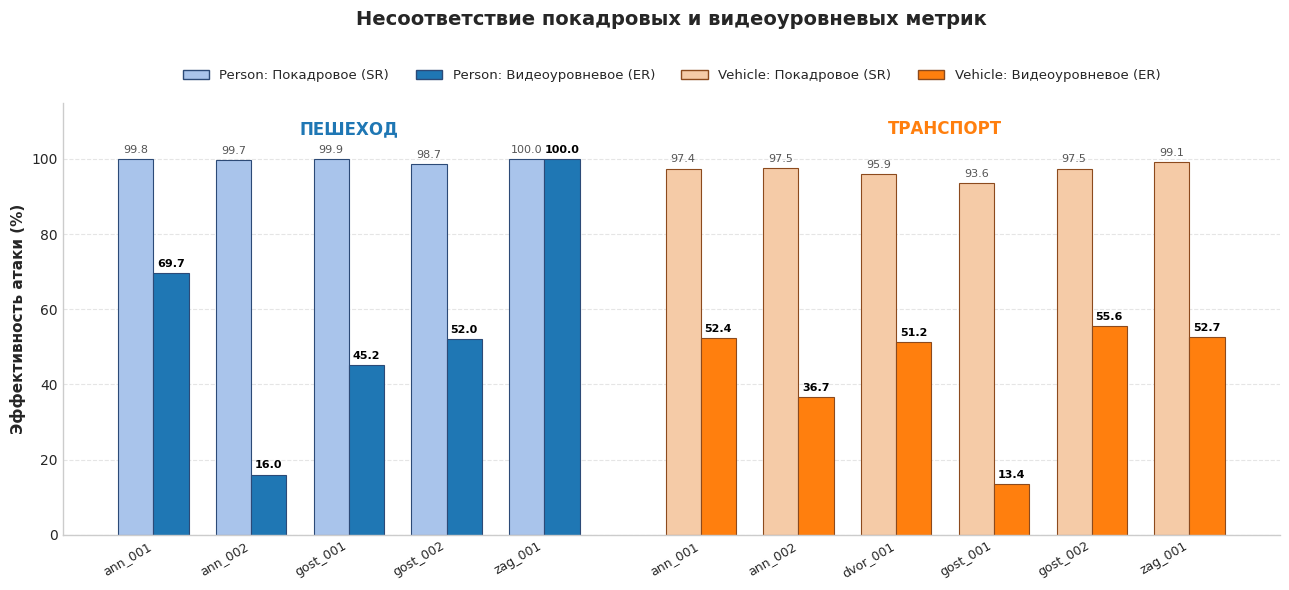

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Thiết lập style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Dữ liệu
data_per = [
    {"vid": "ann_001",  "sr": 99.85, "er": 69.7},
    {"vid": "ann_002",  "sr": 99.73, "er": 16.0},
    {"vid": "gost_001", "sr": 99.90, "er": 45.2},
    {"vid": "gost_002", "sr": 98.66, "er": 52.0},
    {"vid": "zag_001",  "sr": 100.00,"er": 100.0}
]

data_veh = [
    {"vid": "ann_001",  "sr": 97.41, "er": 52.4},
    {"vid": "ann_002",  "sr": 97.51, "er": 36.7},
    {"vid": "dvor_001", "sr": 95.89, "er": 51.2},
    {"vid": "gost_001", "sr": 93.56, "er": 13.4},
    {"vid": "gost_002", "sr": 97.45, "er": 55.6},
    {"vid": "zag_001",  "sr": 99.07, "er": 52.7}
]

# 2. Màu sắc
COLOR_PER_SR = '#A9C4EB' 
COLOR_PER_ER = '#1f77b4' 
COLOR_VEH_SR = '#F5CBA7' 
COLOR_VEH_ER = '#ff7f0e' 

# 3. Tính toán trục X
x_per = np.arange(len(data_per))
gap = 0.6
x_veh = np.arange(len(data_veh)) + len(data_per) + gap
width = 0.36 

# 4. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(13, 6), facecolor='white')
ax.set_facecolor('white')

# --- VẼ CỘT ---
sr_per_vals = [d['sr'] for d in data_per]
er_per_vals = [d['er'] for d in data_per]
rects_per_sr = ax.bar(x_per - width/2, sr_per_vals, width, color=COLOR_PER_SR, edgecolor='#2C4A77', linewidth=0.8)
rects_per_er = ax.bar(x_per + width/2, er_per_vals, width, color=COLOR_PER_ER, edgecolor='#2C4A77', linewidth=0.8)

sr_veh_vals = [d['sr'] for d in data_veh]
er_veh_vals = [d['er'] for d in data_veh]
rects_veh_sr = ax.bar(x_veh - width/2, sr_veh_vals, width, color=COLOR_VEH_SR, edgecolor='#8C4A1D', linewidth=0.8)
rects_veh_er = ax.bar(x_veh + width/2, er_veh_vals, width, color=COLOR_VEH_ER, edgecolor='#8C4A1D', linewidth=0.8)

# 5. Hàm ghi text lên đỉnh cột
def autolabel(rects, is_er=False):
    for rect in rects:
        height = rect.get_height()
        font_weight = 'bold' if is_er else 'normal'
        text_color = 'black' if is_er else '#555555'
        
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, 
                    fontweight=font_weight, color=text_color)

autolabel(rects_per_sr, is_er=False)
autolabel(rects_per_er, is_er=True)
autolabel(rects_veh_sr, is_er=False)
autolabel(rects_veh_er, is_er=True)

# 6. Kẻ vạch phân chia và Tiêu đề khu vực
divider_x = len(data_per) - 0.5 + (gap/2)
#ax.axvline(divider_x, color='gray', linestyle='-.', linewidth=1.5, alpha=0.5)

ax.text(len(data_per)/2 - 0.5, 108, 'ПЕШЕХОД', 
        ha='center', va='center', fontsize=12, fontweight='bold', color=COLOR_PER_ER)
ax.text(len(data_per) + gap + len(data_veh)/2 - 0.5, 108, 'ТРАНСПОРТ', 
        ha='center', va='center', fontsize=12, fontweight='bold', color=COLOR_VEH_ER)

# 7. Định dạng trục Y và Tiêu đề chính
ax.set_ylabel('Эффективность атаки (%)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115) 

# CHÚ Ý: Tăng pad=40 để đẩy Tiêu đề lên cao, tạo chỗ trống cho Legend
plt.title('Несоответствие покадровых и видеоуровневых метрик\n', 
          fontsize=14, fontweight='bold', pad=40)

# 8. Gắn nhãn trục X 
all_x = list(x_per) + list(x_veh)
all_labels = [d['vid'] for d in data_per] + [d['vid'] for d in data_veh]

ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, rotation=30, ha='right', fontsize=9)

# Lưới và bỏ viền
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==============================================================================
# 9. ĐIỀU CHỈNH LEGEND (ĐẶT Ở GIỮA, NGAY DƯỚI TIÊU ĐỀ)
# ==============================================================================
legend_elements = [
    mpatches.Patch(facecolor=COLOR_PER_SR, edgecolor='#2C4A77', label='Person: Покадровое (SR)'),
    mpatches.Patch(facecolor=COLOR_PER_ER, edgecolor='#2C4A77', label='Person: Видеоуровневое (ER)'),
    mpatches.Patch(facecolor=COLOR_VEH_SR, edgecolor='#8C4A1D', label='Vehicle: Покадровое (SR)'),
    mpatches.Patch(facecolor=COLOR_VEH_ER, edgecolor='#8C4A1D', label='Vehicle: Видеоуровневое (ER)')
]

# - loc='lower center': Điểm neo là mép dưới giữa của hộp Legend
# - bbox_to_anchor=(0.5, 1.02): Đặt ở vị trí X=0.5 (chính giữa), Y=1.02 (Ngay phía trên biểu đồ)
# - ncol=4: Dàn thành 1 hàng ngang duy nhất
# - frameon=False: Xóa viền của hộp Legend cho thanh thoát
ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.02), 
          ncol=4, fontsize=9.5, frameon=False)
# ==============================================================================

plt.tight_layout()
plt.savefig('metrics_paradox_split_class_fixed_legend.png', dpi=300, bbox_inches='tight')
plt.show()